---
title: Sentinel 1 Surface Soil Moisture (SSM)
subtitle: Learn how to compute surface soil moisture from Sentinel-1 data
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-01-13
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing", "Sentinel-1", "soil moisture", "radar", "SAR"]
tags: ["Sentinel-1", "Soil Moisture", "SSM", "Radar", "SAR", "Earth Observation", "Remote Sensing"]
releaseDate: 2026-01-13
datePublished: 2026-01-13
dateModified: 2026-01-13
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

- [Introduction](#Introduction_SSM)
- [Setup](#Setup_SSM)
- [Configuration](#Configuration_SSM)
- [Helper functions](#Helper-functions_SSM)
- [Creating a reference period datacute](#Creating-reference-period-datacube_SSM)
- [Preprocess reference period data](#Preprocess-reference-period-data_SSM)
- [Geocode reference period data](#Geocode-reference-period-data_SSM)
- [Calculate dry and wet references](#Calculate-dry-and-wet-references_SSM)
- [Search current period data](#Search-current-period-data_SSM)
- [Process current observations](#Process-current-observations_SSM)
- [Calculate surface soil moisture](#Calculate-surface-soil-moisture_SSM)
- [Filter urban and water areas](#Filter-urban-and-water-areas_SSM)
- [Visualize results](#Visualize-results_SSM)

(Introduction_SSM)=
## Introduction

In this notebook, we will demonstrate how to compute surface soil moisture (SSM) from Sentinel-1 data using EOPF Zarr data. Surface soil moisture is a crucial parameter for various applications, including agriculture, hydrology, and climate studies.

The original notebook comes from the [Copernicus Data Space Ecosystem](https://documentation.dataspace.copernicus.eu/APIs/openEO/openeo-community-examples/python/SurfaceSoilMoisture/SoilMoisture.html)

:::{hint} Overview
**Questions**
- How can we estimate Surface Soil Moisture from Sentinel-1 data?
- How can we compute the difference between the reference and current data?

**Objectives**
- Learn how to create and preprocess Sentinel-1 data
- Perform geocoding, spatial slicing, interpolation
- Compute Surface Soil Moisture
:::

(Setup_SSM)=
## Setup
Start importing the necessary libraries

In [1]:
import pystac_client
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

xr.set_options(display_expand_attrs=False)

(Configuration_SSM)=
## Configuration

In [ ]:
# Bounding box [min_lon, min_lat, max_lon, max_lat]
bbox = [139.400, -35.400, 139.450, -35.350]

# Reference period (for establishing dry and wet conditions)
reference_start = "2017-02-02"
reference_end = "2020-02-02"

# Current period (observation to calculate SSM for)
current_start = "2020-01-02"
current_end = "2020-01-28"

# Spatial resolution for geocoded output (degrees)
spatial_resolution = 0.0001

# STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

(Helper-functions_SSM)=
## Helper functions

In [3]:
def build_slice(shape, idx, offset=2):
    i0 = int(min(idx[0]))
    i1 = int(max(idx[1]))

    def clamp_slice(i, dim_size):
        start = max(0, i - offset)
        end = min(dim_size - 1, i + offset)
        return slice(start, end + 1)

    return [clamp_slice(i0, shape[0]), clamp_slice(i1, shape[1])]

In [4]:
def create_regular_grid(min_x, max_x, min_y, max_y, spatialres):
    width = int(np.ceil((max_x - min_x) / spatialres))
    height = int(np.ceil((max_y - min_y) / spatialres))

    half_pixel = spatialres / 2.0
    x_regular = np.linspace(
        min_x + half_pixel, max_x - half_pixel, width, dtype=np.float32
    )
    y_regular = np.linspace(
        min_y + half_pixel, max_y - half_pixel, height, dtype=np.float32
    )

    grid_x_regular, grid_y_regular = np.meshgrid(x_regular, y_regular)

    return grid_x_regular, grid_y_regular

In [5]:
def geocode_grd(sigma_0, grid_x_regular, grid_y_regular):
    grid_lat = sigma_0.latitude.values
    grid_lon = sigma_0.longitude.values

    # Set border values to zero to avoid artifacts
    sigma_0["vh"].data[[0, -1], :] = 0
    sigma_0["vh"].data[:, [0, -1]] = 0
    sigma_0["vv"].data[[0, -1], :] = 0
    sigma_0["vv"].data[:, [0, -1]] = 0

    interpolated_values_grid_vh = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vh.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    interpolated_values_grid_vv = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vv.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    ds = xr.Dataset(
        coords=dict(
            time=(["time"], [sigma_0.time.values]),
            y=(["y"], grid_y_regular[:, 0]),
            x=(["x"], grid_x_regular[0, :]),
        )
    )
    ds["vh"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vh, 0))
    ds["vv"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vv, 0))
    ds = ds.where(ds != 0)

    return ds

In [7]:
def preprocess_grd(grd_path, bbox):
    # Data Access
    dt = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"][:-2], "ns")

    group_VH = [x for x in dt.children if "VH" in x][0]
    grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
    group_VV = [x for x in dt.children if "VV" in x][0]
    grd["vv"] = dt[group_VV].measurements.to_dataset().grd

    # Spatial Slicing
    gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
    mask = (
        (gcps.latitude < bbox[3])
        & (gcps.latitude > bbox[1])
        & (gcps.longitude < bbox[2])
        & (gcps.longitude > bbox[0])
    )
    idx = np.where(mask == 1)
    if len(idx[0]) == 0 or len(idx[1]) == 0:
        return None
    azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

    gcps_crop = gcps.isel(
        dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
    )

    azimuth_time_min = gcps_crop.azimuth_time.min().values
    azimuth_time_max = gcps_crop.azimuth_time.max().values

    ground_range_min = gcps_crop.ground_range.min().values
    ground_range_max = gcps_crop.ground_range.max().values

    grd_crop = grd.sel(
        dict(
            azimuth_time=slice(azimuth_time_min, azimuth_time_max),
            ground_range=slice(ground_range_min, ground_range_max),
        )
    )

    gcps_crop_interp = gcps_crop.interp_like(grd_crop)
    grd_crop = grd_crop.assign_coords(
        {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
    )
    mask_2 = (
        (gcps_crop_interp.latitude < bbox[3])
        & (gcps_crop_interp.latitude > bbox[1])
        & (gcps_crop_interp.longitude < bbox[2])
        & (gcps_crop_interp.longitude > bbox[0])
    )
    grd_crop = grd_crop.where(mask_2.compute(), drop=True)

    # Calibration
    sigma_lut = dt[group_VH].quality.calibration.sigma_nought

    sigma_lut_line_pixel = xr.DataArray(
        data=sigma_lut.data,
        dims=["line", "pixel"],
        coords=dict(
            line=(["line"], sigma_lut.line.values),
            pixel=(["pixel"], sigma_lut.pixel.values),
        ),
    )
    grd_line_pixel = xr.DataArray(
        data=grd_crop.vh.data,
        dims=["line", "pixel"],
        coords=dict(
            line=(["line"], grd_crop.vh.line.values),
            pixel=(["pixel"], grd_crop.vh.pixel.values),
        ),
    )
    sigma_lut_interp_line_pixel = sigma_lut_line_pixel.interp_like(
        grd_line_pixel, method="linear"
    )

    sigma_lut_interp = xr.DataArray(
        data=sigma_lut_interp_line_pixel.data,
        dims=["azimuth_time", "ground_range"],
        coords=dict(
            azimuth_time=(["azimuth_time"], grd_crop.azimuth_time.values),
            ground_range=(["ground_range"], grd_crop.ground_range.values),
        ),
    )

    sigma_0 = (abs(grd_crop.astype(np.float32)) ** 2) / (sigma_lut_interp**2)
    sigma_0 = sigma_0.assign_coords(time=t)

    sigma_0 = sigma_0.compute()

    return [
        sigma_0,
        (
            np.min(sigma_0.latitude.values).item(),
            np.max(sigma_0.latitude.values).item(),
        ),
        (
            np.min(sigma_0.longitude.values).item(),
            np.max(sigma_0.longitude.values).item(),
        ),
    ]

(Creating-reference-period-datacube_SSM)=
## Creating a reference period datacube

In [8]:
ref_items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=[reference_start, reference_end],
    ).items()
)
print(f"Found {len(ref_items)} reference images")

grd_paths_ref = [p.assets["product"].href for p in ref_items]

Found 91 reference images


(Preprocess-reference-period-data_SSM)=
## Preprocess reference period data

In [ ]:
%%time

from concurrent.futures import ThreadPoolExecutor, as_completed

grd_products = []
max_workers = 2

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_path = {
        executor.submit(preprocess_grd, grd_path, bbox): grd_path
        for grd_path in grd_paths_ref
    }

    for i, future in enumerate(as_completed(future_to_path), 1):
        try:
            result = future.result()
            if result is not None:
                grd_products.append(result)
        except Exception:
            grd_path = future_to_path[future]

print(f"\nSuccessfully preprocessed {len(grd_products)} images")


Successfully preprocessed 91 images
CPU times: user 2min 6s, sys: 1min 8s, total: 3min 15s
Wall time: 2min 1s


(Geocode-reference-period-data_SSM)=
## Geocode reference period data

In [10]:
min_lat = np.min([i[1][0] for i in grd_products])
max_lat = np.max([i[1][1] for i in grd_products])
min_lon = np.min([i[2][0] for i in grd_products])
max_lon = np.max([i[2][1] for i in grd_products])

grid_x_regular, grid_y_regular = create_regular_grid(
    min_lon, max_lon, min_lat, max_lat, spatial_resolution
)

print(f"Grid shape: {grid_y_regular.shape}")

Grid shape: (723, 823)


In [11]:
%%time
from concurrent.futures import ThreadPoolExecutor, as_completed
import gc

grd_products_geocoded = []

with ThreadPoolExecutor(max_workers=2) as executor:
    futures = [
        executor.submit(geocode_grd, grd_product[0], grid_x_regular, grid_y_regular)
        for grd_product in grd_products
    ]

    for i, future in enumerate(as_completed(futures), 1):
        result = future.result()
        grd_products_geocoded.append(result)

        if i % 10 == 0:
            gc.collect()

print(f"\nGeocoded {len(grd_products_geocoded)} products")

sigma_0_ref_series = xr.concat(grd_products_geocoded, dim="time").sortby("time")
sigma_0_ref_series = (
    sigma_0_ref_series.groupby("time.date").max("time").rename(dict(date="time"))
)
sigma_0_ref_series = sigma_0_ref_series.where(~np.isnan(sigma_0_ref_series), drop=True)

sigma_0_ref_series


Geocoded 91 products
CPU times: user 3min 16s, sys: 1.32 s, total: 3min 17s
Wall time: 1min 40s


<xarray.Dataset> Size: 365MB
Dimensions:  (time: 91, y: 501, x: 501)
Coordinates:
  * y        (y) float32 2kB -35.4 -35.4 -35.4 -35.4 ... -35.35 -35.35 -35.35
  * x        (x) float32 2kB 139.4 139.4 139.4 139.4 ... 139.4 139.4 139.4 139.4
  * time     (time) object 728B 2017-02-02 2017-02-14 ... 2020-01-18 2020-01-30
Data variables:
    vh       (time, y, x) float64 183MB nan nan nan nan ... nan nan nan nan
    vv       (time, y, x) float64 183MB nan nan nan nan ... nan nan nan nan

(Calculate-dry-and-wet-references_SSM)=
## Calculate dry and wet references

In [12]:
# Dry reference = minimum backscatter (driest conditions)
dry_ref = sigma_0_ref_series.min(dim="time")

# Wet reference = maximum backscatter (wettest conditions)
wet_ref = sigma_0_ref_series.max(dim="time")

(Search-current-period-data_SSM)=
## Search current period data

In [13]:
cur_items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=[current_start, current_end],
    ).items()
)

grd_path_current = [p.assets["product"].href for p in cur_items][-1]

(Process-current-observations_SSM)=
## Process current observations

In [14]:
%%time

grd_product_current = preprocess_grd(grd_path_current, bbox)

sigma_0_current = geocode_grd(grd_product_current[0], grid_x_regular, grid_y_regular)

sigma_0_current = sigma_0_current.isel(time=0)
sigma_0_current

CPU times: user 3.81 s, sys: 707 ms, total: 4.52 s
Wall time: 6.85 s


<xarray.Dataset> Size: 10MB
Dimensions:  (y: 723, x: 823)
Coordinates:
    time     datetime64[ns] 8B 2020-01-06T19:57:35.085440
  * y        (y) float32 3kB -35.41 -35.41 -35.41 ... -35.34 -35.34 -35.34
  * x        (x) float32 3kB 139.4 139.4 139.4 139.4 ... 139.5 139.5 139.5 139.5
Data variables:
    vh       (y, x) float64 5MB nan nan nan nan nan nan ... nan nan nan nan nan
    vv       (y, x) float64 5MB nan nan nan nan nan nan ... nan nan nan nan nan

(Calculate-surface-soil-moisture_SSM)=
## Calculate surface soil moisture

In [15]:
# SSM = (current - dry) / (wet - dry)
SSM_vv = (sigma_0_current.vv - dry_ref.vv) / (wet_ref.vv - dry_ref.vv)
SSM_vh = (sigma_0_current.vh - dry_ref.vh) / (wet_ref.vh - dry_ref.vh)

# Clip to [0, 1] range
SSM_vv = SSM_vv.clip(0, 1)
SSM_vh = SSM_vh.clip(0, 1)

(Filter-urban-and-water-areas_SSM)=
## Filter urban and water areas

In [25]:
average_ref = sigma_0_ref_series.mean(dim="time")

average_ref_db = 10 * np.log10(average_ref)

In [30]:
VV_db = average_ref_db.vv
mask = (VV_db > -13) | (VV_db < -24)

# Apply mask to SSM (mask out urban and water areas)
SSM_vv_filtered = SSM_vv.where(~mask)

pixels_masked = int(mask.sum().values)
total_pixels = int(mask.size)
print(f"\nMasked pixels: {pixels_masked} ({100*pixels_masked/total_pixels:.1f}%)")


Masked pixels: 1503 (0.6%)


(Visualize-results_SSM)=
## Visualize results

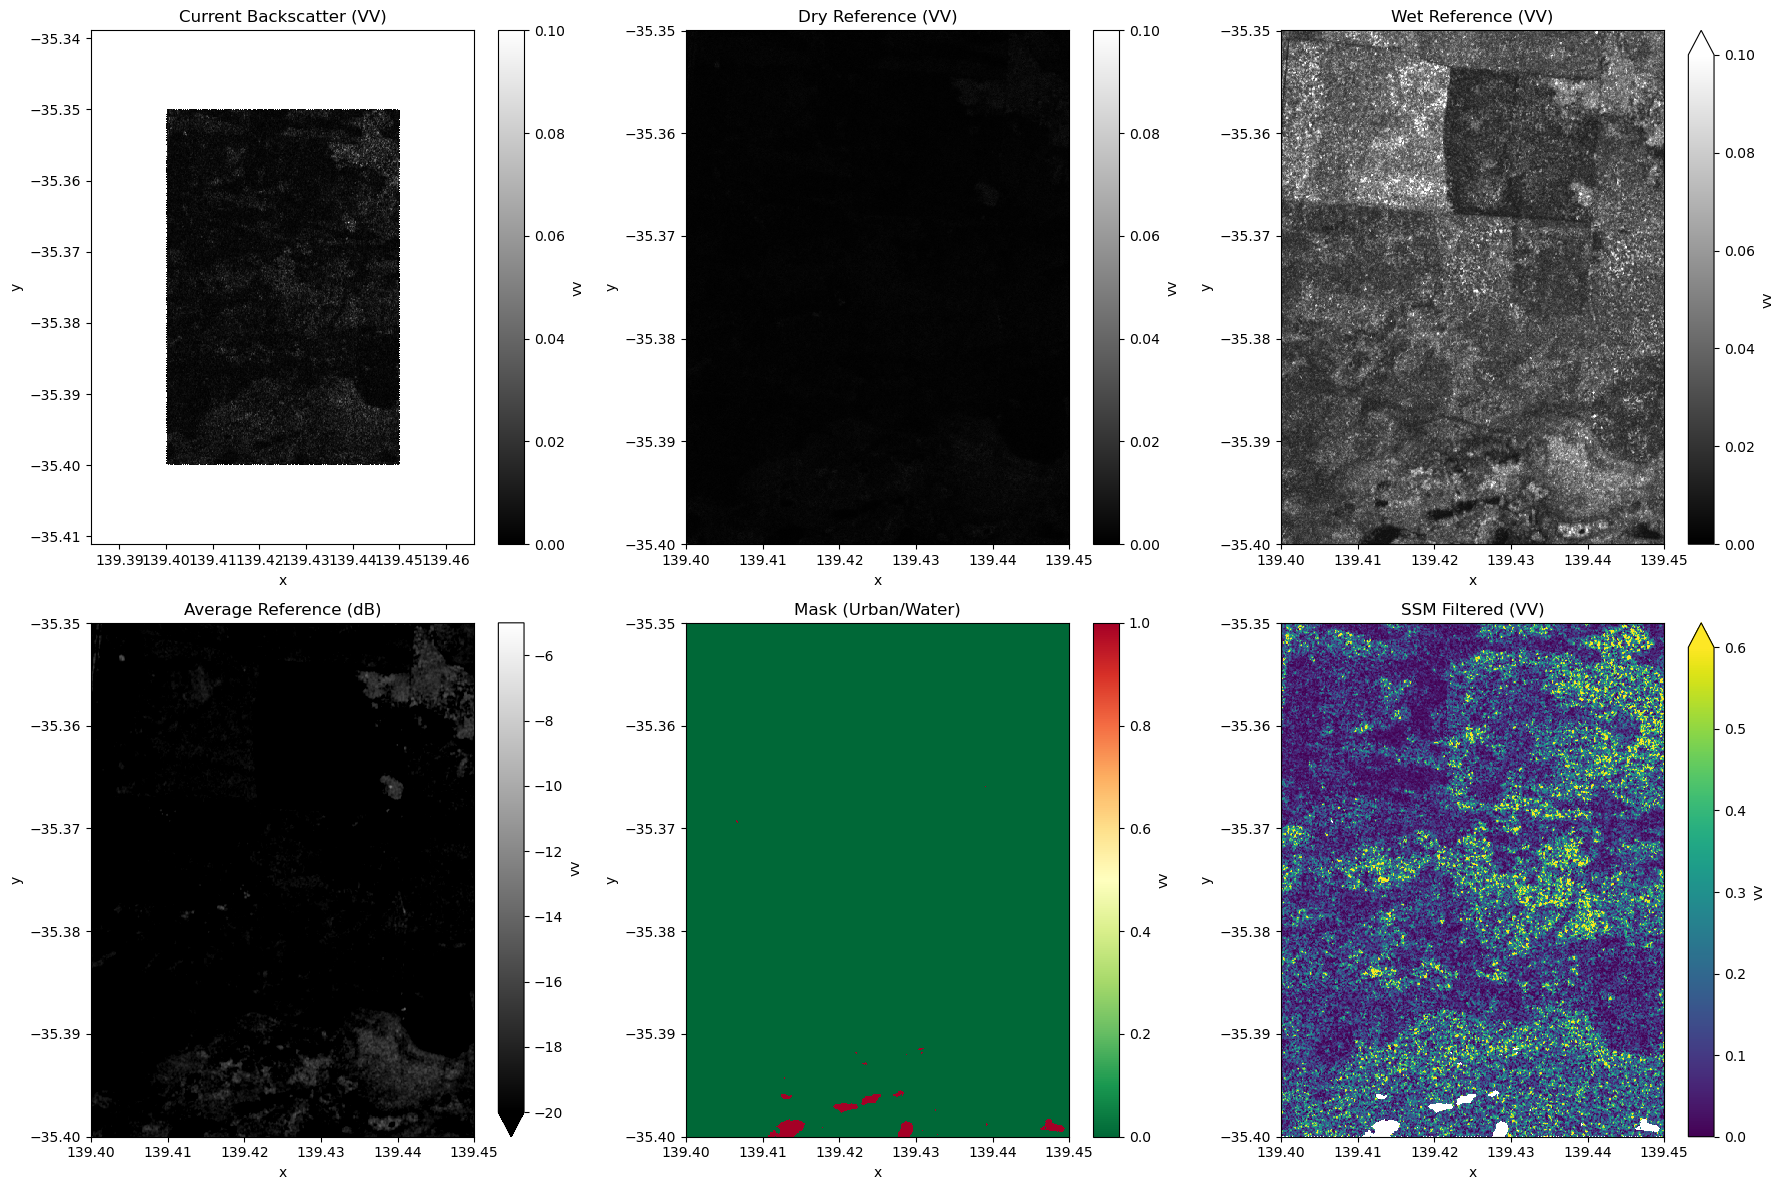

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sigma_0_current.vv.plot.imshow(
    ax=axes[0, 0], vmin=0, vmax=0.1, cmap="gray", add_colorbar=True
)
axes[0, 0].set_title("Current Backscatter (VV)", fontsize=12)

dry_ref.vv.plot.imshow(ax=axes[0, 1], vmin=0, vmax=0.1, cmap="gray", add_colorbar=True)
axes[0, 1].set_title("Dry Reference (VV)", fontsize=12)

wet_ref.vv.plot.imshow(ax=axes[0, 2], vmin=0, vmax=0.1, cmap="gray", add_colorbar=True)
axes[0, 2].set_title("Wet Reference (VV)", fontsize=12)

average_ref_db.vv.plot.imshow(
    ax=axes[1, 0], vmin=-20, vmax=-5, cmap="gray", add_colorbar=True
)
axes[1, 0].set_title("Average Reference (dB)", fontsize=12)

mask.plot.imshow(ax=axes[1, 1], cmap="RdYlGn_r", add_colorbar=True)
axes[1, 1].set_title("Mask (Urban/Water)", fontsize=12)

SSM_vv_filtered.plot.imshow(
    ax=axes[1, 2], vmin=0, vmax=0.6, cmap="viridis", add_colorbar=True
)
axes[1, 2].set_title("SSM Filtered (VV)", fontsize=12)

plt.tight_layout()
plt.show()

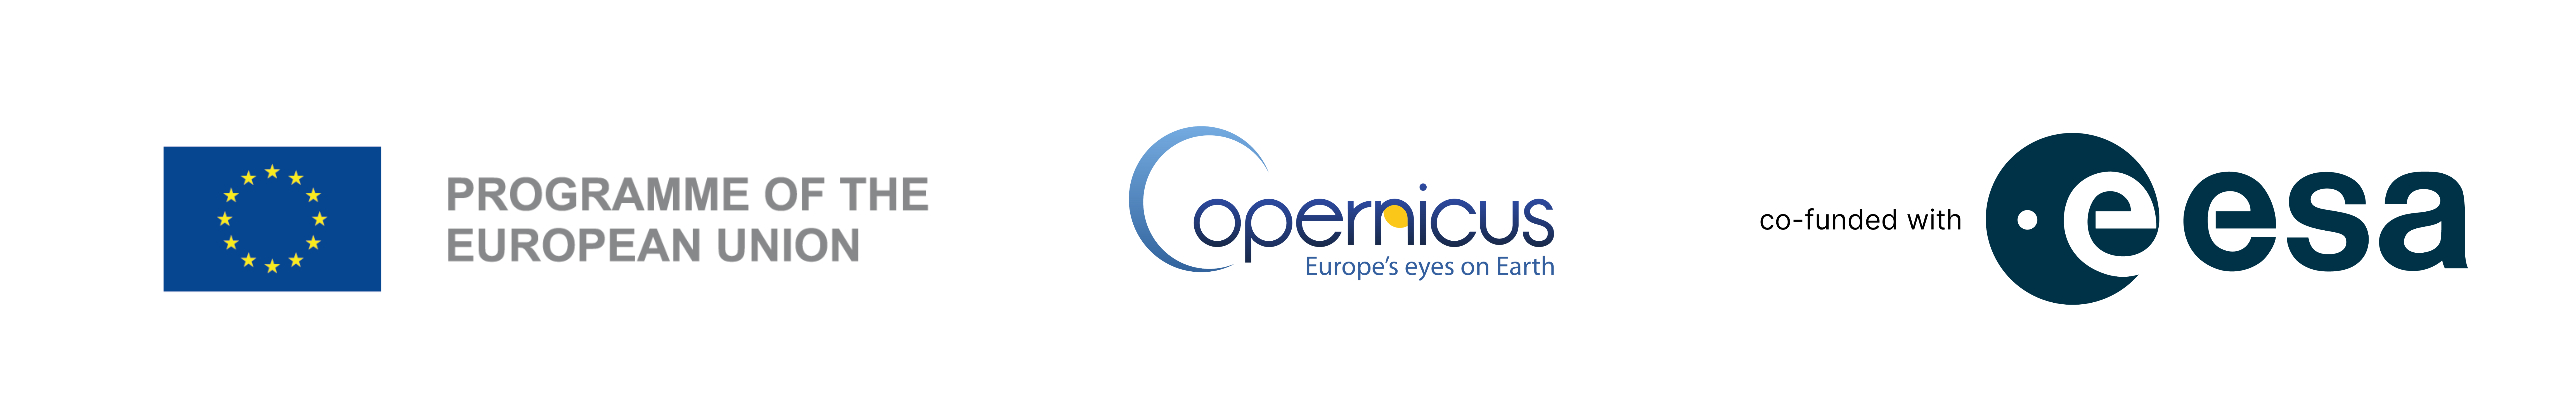